In [ ]:

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, MultiLabelBinarizer
from sklearn.ensemble import RandomForestClassifier 
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
# dataframe ko load kar rahe hai.
try:
    df = pd.read_csv('Carbon Emission.csv')
    print("Dataset loaded successfully!")
except FileNotFoundError:
    print("Error: The file 'Carbon Emission.csv' was not found.")
    print("Please ensure the file is in the same directory as this notebook.")

# Create a categorical target variable by binning CarbonEmission
# We will create three bins: 'Low', 'Medium', and 'High'
bins = [0, 1500, 2500, np.inf]
labels = ['Low', 'Medium', 'High']
df['CarbonEmission_Category'] = pd.cut(df['CarbonEmission'], bins=bins, labels=labels)

# Separate features (X) and the new categorical target (y)
y = df['CarbonEmission_Category']
X = df.drop(['CarbonEmission', 'CarbonEmission_Category'], axis=1)

# Display the first few rows with the new category                                                     

Dataset loaded successfully!

First 5 rows of the dataset with new category:
    Body Type     Sex         Diet How Often Shower Heating Energy Source  \
0  overweight  female  pescatarian            daily                  coal   
1       obese  female   vegetarian  less frequently           natural gas   
2  overweight    male     omnivore  more frequently                  wood   
3  overweight    male     omnivore      twice a day                  wood   
4       obese  female   vegetarian            daily                  coal   

      Transport Vehicle Type Social Activity  Monthly Grocery Bill  \
0        public          NaN           often                   230   
1  walk/bicycle          NaN           often                   114   
2       private       petrol           never                   138   
3  walk/bicycle          NaN       sometimes                   157   
4       private       diesel           often                   266   

  Frequency of Traveling by Air  ...  W

In [3]:
categorical_features = ['Body Type', 'Sex', 'Diet', 'How Often Shower',
                        'Heating Energy Source', 'Transport', 'Vehicle Type',
                        'Social Activity', 'Frequency of Traveling by Air',
                        'Energy efficiency', 'Waste Bag Size']
list_like_features = ['Recycling', 'Cooking_With']
numerical_features = X.select_dtypes(include=np.number).columns.tolist()

# Define a function to process the string representation of lists
def process_list_string(s):
    try:
        return eval(s.replace("'", "")) if pd.notna(s) else []
    except (NameError, TypeError, SyntaxError):
        return []

# Apply the function to the list-like columns
X['Recycling_list'] = X['Recycling'].apply(process_list_string)
X['Cooking_With_list'] = X['Cooking_With'].apply(process_list_string)

# Use OneHotEncoder for standard categorical columns
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
X_categorical_encoded = ohe.fit_transform(X[categorical_features])
X_categorical_df = pd.DataFrame(X_categorical_encoded, columns=ohe.get_feature_names_out(categorical_features))

# Use MultiLabelBinarizer for list-like columns
mlb_recycling = MultiLabelBinarizer()
X_recycling_encoded = mlb_recycling.fit_transform(X['Recycling_list'])
X_recycling_df = pd.DataFrame(X_recycling_encoded, columns=[f'Recycling_{c}' for c in mlb_recycling.classes_])

mlb_cooking = MultiLabelBinarizer()
X_cooking_encoded = mlb_cooking.fit_transform(X['Cooking_With_list'])
X_cooking_df = pd.DataFrame(X_cooking_encoded, columns=[f'Cooking_{c}' for c in mlb_cooking.classes_])

# Combine all processed features into a single DataFrame
X_processed = pd.concat([X[numerical_features], X_categorical_df, X_recycling_df, X_cooking_df], axis=1)

print("\nProcessed features DataFrame shape:", X_processed.shape)


Processed features DataFrame shape: (10000, 47)


In [4]:
X_train, X_test, y_train, y_test = train_test_split(X_processed, y, test_size=0.2, random_state=42)

# Initialize and train the RandomForestClassifier model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

print("Model training complete!")

Model training complete!


In [5]:
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.2f}")

cm = confusion_matrix(y_test, y_pred, labels=['Low', 'Medium', 'High'])
print("\nConfusion Matrix:")
print(cm)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Model Accuracy: 0.83

Confusion Matrix:
[[341  94   0]
 [ 60 730 102]
 [  0  80 593]]

Classification Report:
              precision    recall  f1-score   support

        High       0.85      0.88      0.87       673
         Low       0.85      0.78      0.82       435
      Medium       0.81      0.82      0.81       892

    accuracy                           0.83      2000
   macro avg       0.84      0.83      0.83      2000
weighted avg       0.83      0.83      0.83      2000



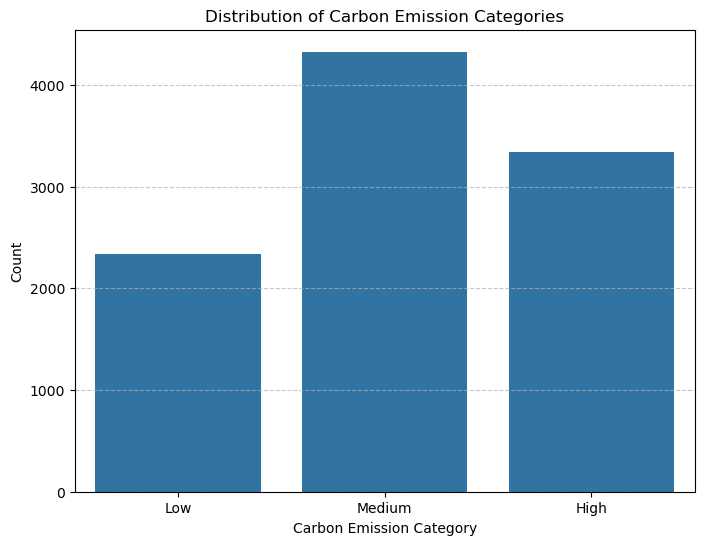

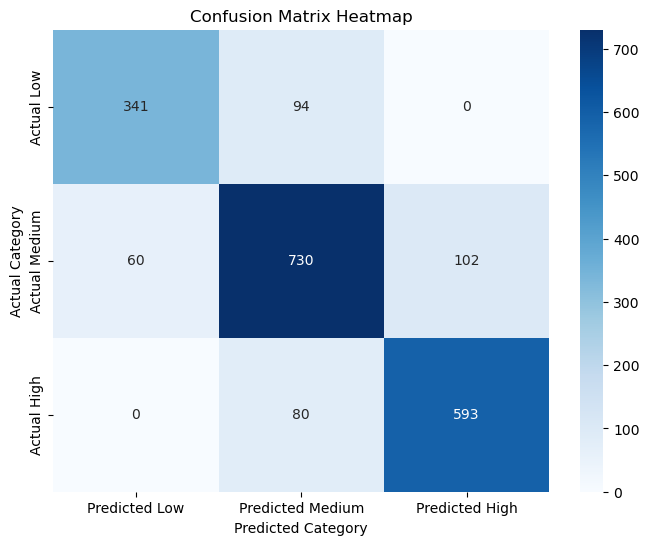

In [6]:
plt.figure(figsize=(8, 6))
sns.countplot(x='CarbonEmission_Category', data=df, order=['Low', 'Medium', 'High'])
plt.title('Distribution of Carbon Emission Categories')
plt.xlabel('Carbon Emission Category')
plt.ylabel('Count')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Low', 'Predicted Medium', 'Predicted High'],
            yticklabels=['Actual Low', 'Actual Medium', 'Actual High'])
plt.title('Confusion Matrix Heatmap')
plt.xlabel('Predicted Category')
plt.ylabel('Actual Category')
plt.show()